# Entscheidungsbäume: rekursive Partitionierung von Grund auf

**Notebook 04 der Reihe *Algorithmen des Maschinellen Lernens***

Autor: Mark Baumann · Sprache: Deutsch · Kernel: Python 3

---

## Zusammenfassung

Entscheidungsbäume partitionieren den Merkmalsraum rekursiv entlang einzelner Achsen
und erzeugen dadurch — im Gegensatz zu k-NN (Notebook 03) — ein **interpretierbares**
Regelwerk. Dieses Notebook leitet den gierigen Split-Algorithmus über
Unreinheitsmaße (Gini, Entropie) und Informationsgewinn her, implementiert ihn
vollständig mit `NumPy`, untersucht Overfitting über `max_depth`, vergleicht Gini und
Entropie sowie die Baum- mit der linearen Entscheidungsgrenze aus Notebook 02, und
validiert die Implementierung gegen `scikit-learn`.

## Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. Gini-Unreinheit und Entropie herleiten und ihre Gemeinsamkeiten/Unterschiede
   benennen,
2. den Informationsgewinn eines Splits berechnen und den gierigen Baumaufbau
   algorithmisch nachvollziehen,
3. den Zusammenhang zwischen `max_depth` und dem Bias-Varianz-Tradeoff (Notebook 00,
   Abschnitt 5) an achsenparallelen Entscheidungsgrenzen erkennen,
4. die Instabilität einzelner Bäume gegenüber kleinen Datenänderungen demonstrieren,
5. begründen, warum Ensembles (Random Forests, Boosting) die zentralen Schwächen
   einzelner Bäume adressieren.

## Inhalt

1. [Theoretischer Rahmen](#1)
2. [Rechenumgebung](#2)
3. [Datengrundlage](#3)
4. [Implementierung](#4)
5. [Empirische Analyse](#5)
6. [Diskussion und Grenzen](#6)
7. [Übungsaufgaben](#7)
8. [Literatur](#8)

<a id="1"></a>
## 1 Theoretischer Rahmen

### 1.1 Rekursive Partitionierung

Ein Entscheidungsbaum zerlegt den Merkmalsraum rekursiv in achsenparallele Rechtecke.
An jedem inneren Knoten wird ein Merkmal $j$ und ein Schwellenwert $\tau$ gewählt, die
die Knotendaten in $\{\mathbf{x}: x_j \le \tau\}$ und $\{\mathbf{x}: x_j > \tau\}$
aufteilen. Für Klassifikation wird jedem Blatt die Mehrheitsklasse seiner Trainingspunkte
zugewiesen.

### 1.2 Unreinheitsmaße

Für einen Knoten mit Klassenanteilen $p_1,\dots,p_C$ ($\sum_c p_c=1$) sind die
gebräuchlichsten Unreinheitsmaße

$$
\text{Gini: } \; G = 1 - \sum_{c=1}^{C} p_c^2,
\qquad\qquad
\text{Entropie: } \; H = -\sum_{c=1}^{C} p_c \log_2 p_c
$$

(mit der Konvention $0\log_2 0 = 0$). Beide sind null bei einem reinen Knoten
($p_c=1$ für ein $c$) und maximal bei Gleichverteilung; die Entropie stammt aus der
Informationstheorie (erwartete Bits zur Kodierung des Klassenlabels), Gini ist
rechnerisch günstiger, da kein Logarithmus benötigt wird.

### 1.3 Informationsgewinn und Split-Suche

Für einen Split, der einen Elternknoten mit $n$ Beobachtungen in einen linken
($n_L$ Beobachtungen) und rechten Kindknoten ($n_R=n-n_L$) teilt, ist der
**Informationsgewinn**

$$
\Delta = I_{\text{Eltern}} - \left(\frac{n_L}{n} I_L + \frac{n_R}{n} I_R\right),
$$

wobei $I$ das gewählte Unreinheitsmaß bezeichnet. Der Algorithmus (CART, Breiman et
al., 1984) durchsucht **gierig** ("greedy") alle Merkmale und alle beobachteten
Schwellenwerte, wählt den Split mit maximalem $\Delta$ und wiederholt dies rekursiv in
jedem Kindknoten, bis ein Abbruchkriterium (maximale Tiefe, minimale Knotengröße,
Reinheit) erreicht ist. "Gierig" bedeutet: Der Split wird lokal optimal für den
aktuellen Knoten gewählt, ohne Rücksicht auf zukünftige Splits — der resultierende Baum
ist im Allgemeinen **nicht** global optimal (Abschnitt 6).

### 1.4 Komplexität und Overfitting

Ohne Tiefenbegrenzung kann ein Baum jeden Trainingspunkt perfekt klassifizieren (im
Extremfall ein Blatt pro Punkt) — Trainingsfehler null, aber massives Overfitting
(Notebook 00, Abschnitt 5: minimaler Bias, sehr hohe Varianz). `max_depth`,
`min_samples_split` und Pruning-Verfahren begrenzen die Modellkomplexität und damit die
Varianz auf Kosten eines höheren Bias.

In [1]:
from __future__ import annotations

import sys
from collections import Counter

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

mpl.rcParams.update(
    {
        "figure.figsize": (7.0, 4.5), "figure.dpi": 110, "font.size": 10,
        "axes.grid": True, "axes.axisbelow": True,
        "axes.spines.top": False, "axes.spines.right": False,
        "grid.alpha": 0.3, "legend.frameon": False,
    }
)
pd.set_option("display.precision", 4)
print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}")

Python 3.11.15, NumPy 2.4.6


<a id="3"></a>
## 3 Datengrundlage

Als Beispiel dient wieder der Halbmond-Datensatz aus Notebook 03, um die
achsenparallele Entscheidungsgrenze eines Baums direkt mit der lokal-glatten Grenze von
k-NN und der linearen Grenze der logistischen Regression zu vergleichen.

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=300, noise=0.25, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f"n_train={len(X_train)}, n_test={len(X_test)}")

n_train=210, n_test=90


<a id="4"></a>
## 4 Implementierung

In [3]:
class DecisionTreeNode:
    """Ein Knoten des Entscheidungsbaums (Blatt oder innerer Knoten)."""

    __slots__ = ("feature_index", "threshold", "left", "right", "value", "is_leaf", "n_samples", "impurity")

    def __init__(self) -> None:
        self.feature_index: int | None = None
        self.threshold: float | None = None
        self.left: "DecisionTreeNode | None" = None
        self.right: "DecisionTreeNode | None" = None
        self.value: int | None = None
        self.is_leaf: bool = False
        self.n_samples: int = 0
        self.impurity: float = 0.0


class DecisionTree:
    """Entscheidungsbaum-Klassifikator (CART, ohne Pruning).

    Parameters
    ----------
    max_depth : int, default=5
        Maximale Tiefe des Baums.
    min_samples_split : int, default=2
        Minimale Knotengroesse, damit ein Split ueberhaupt versucht wird.
    criterion : {"gini", "entropy"}, default="gini"
        Unreinheitsmass fuer die Split-Suche (Abschnitt 1.2).

    Attributes
    ----------
    root_ : DecisionTreeNode
        Wurzel des angepassten Baums.
    """

    def __init__(self, max_depth: int = 5, min_samples_split: int = 2, criterion: str = "gini") -> None:
        if criterion not in ("gini", "entropy"):
            raise ValueError("criterion muss 'gini' oder 'entropy' sein")
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.root_: DecisionTreeNode | None = None

    def _impurity(self, y: np.ndarray) -> float:
        """Berechnet Gini- oder Entropie-Unreinheit eines Knotens (Abschnitt 1.2)."""
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        if self.criterion == "gini":
            return 1.0 - np.sum(probs**2)
        probs = probs[probs > 0]
        return float(-np.sum(probs * np.log2(probs)))

    def _best_split(self, X: np.ndarray, y: np.ndarray) -> dict | None:
        """Sucht den Split mit maximalem Informationsgewinn (Abschnitt 1.3)."""
        n_samples, n_features = X.shape
        if n_samples < self.min_samples_split:
            return None

        parent_impurity = self._impurity(y)
        best_gain, best_split = 1e-12, None  # gain > 0 als Mindestanforderung

        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds[:-1]:  # letzter Wert erzeugt leeren rechten Knoten
                left_mask = X[:, feature_idx] <= threshold
                n_left, n_right = int(left_mask.sum()), int((~left_mask).sum())
                if n_left == 0 or n_right == 0:
                    continue

                weighted_impurity = (
                    n_left / n_samples * self._impurity(y[left_mask])
                    + n_right / n_samples * self._impurity(y[~left_mask])
                )
                gain = parent_impurity - weighted_impurity
                if gain > best_gain:
                    best_gain = gain
                    best_split = {"feature_index": feature_idx, "threshold": threshold, "gain": gain}

        return best_split

    def _build(self, X: np.ndarray, y: np.ndarray, depth: int) -> DecisionTreeNode:
        node = DecisionTreeNode()
        node.n_samples = len(y)
        node.impurity = self._impurity(y)

        if depth >= self.max_depth or len(np.unique(y)) == 1:
            node.is_leaf, node.value = True, Counter(y).most_common(1)[0][0]
            return node

        split = self._best_split(X, y)
        if split is None:
            node.is_leaf, node.value = True, Counter(y).most_common(1)[0][0]
            return node

        node.feature_index, node.threshold = split["feature_index"], split["threshold"]
        left_mask = X[:, node.feature_index] <= node.threshold
        node.left = self._build(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build(X[~left_mask], y[~left_mask], depth + 1)
        return node

    def fit(self, X: np.ndarray, y: np.ndarray) -> "DecisionTree":
        """Baut den Baum rekursiv gemaess Abschnitt 1.3 auf."""
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        self.root_ = self._build(X, y, depth=0)
        return self

    def _predict_one(self, x: np.ndarray, node: DecisionTreeNode) -> int:
        if node.is_leaf:
            return node.value
        branch = node.left if x[node.feature_index] <= node.threshold else node.right
        return self._predict_one(x, branch)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Sagt Klassenlabels durch Traversieren des Baums vorher."""
        if self.root_ is None:
            raise RuntimeError("Modell wurde noch nicht angepasst (fit aufrufen).")
        X = np.atleast_2d(np.asarray(X, dtype=np.float64))
        return np.array([self._predict_one(x, self.root_) for x in X])

    def feature_importances(self, n_features: int) -> np.ndarray:
        """Gewichteter Unreinheitsrueckgang je Merkmal, summiert ueber alle Splits."""
        importances = np.zeros(n_features)

        def _walk(node: DecisionTreeNode) -> None:
            if node.is_leaf:
                return
            left_gain = node.n_samples * node.impurity - (
                node.left.n_samples * node.left.impurity + node.right.n_samples * node.right.impurity
            )
            importances[node.feature_index] += left_gain
            _walk(node.left)
            _walk(node.right)

        _walk(self.root_)
        total = importances.sum()
        return importances / total if total > 0 else importances

    def print_tree(self, node: DecisionTreeNode | None = None, depth: int = 0) -> None:
        """Gibt die Baumstruktur textuell aus (Interpretierbarkeit, siehe Abschnitt 5.4)."""
        if node is None:
            node = self.root_
        indent = "  " * depth
        if node.is_leaf:
            print(f"{indent}Blatt: Klasse {node.value} (n={node.n_samples})")
        else:
            print(f"{indent}x[{node.feature_index}] <= {node.threshold:.3f}  "
                  f"({self.criterion}={node.impurity:.3f}, n={node.n_samples})")
            self.print_tree(node.left, depth + 1)
            self.print_tree(node.right, depth + 1)

<a id="5"></a>
## 5 Empirische Analyse

### 5.1 Overfitting über `max_depth`

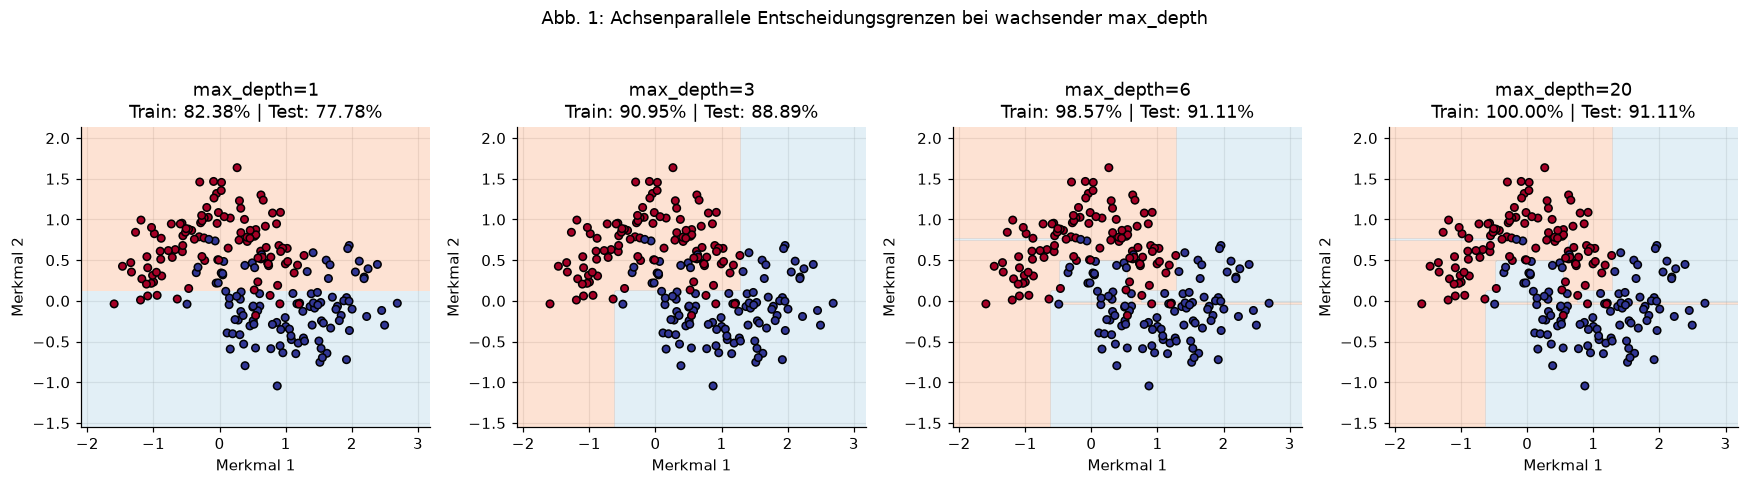

In [4]:
def plot_decision_boundary(model, X, y, title, ax):
    """Zeichnet die Entscheidungsgrenze eines Klassifikators mit .predict(X)."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="RdYlBu", levels=[-0.5, 0.5, 1.5])
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="RdYlBu", s=24)
    ax.set_title(title)
    ax.set_xlabel("Merkmal 1")
    ax.set_ylabel("Merkmal 2")


def accuracy(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


depths = [1, 3, 6, 20]
fig, axes = plt.subplots(1, len(depths), figsize=(16.0, 4.2))
train_accs, test_accs = [], []

for depth, ax in zip(depths, axes):
    tree = DecisionTree(max_depth=depth, criterion="gini").fit(X_train, y_train)
    train_acc = accuracy(y_train, tree.predict(X_train))
    test_acc = accuracy(y_test, tree.predict(X_test))
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    plot_decision_boundary(tree, X_train, y_train,
                            f"max_depth={depth}\nTrain: {train_acc:.2%} | Test: {test_acc:.2%}", ax)
fig.suptitle("Abb. 1: Achsenparallele Entscheidungsgrenzen bei wachsender max_depth", y=1.04)
plt.tight_layout()
plt.show()

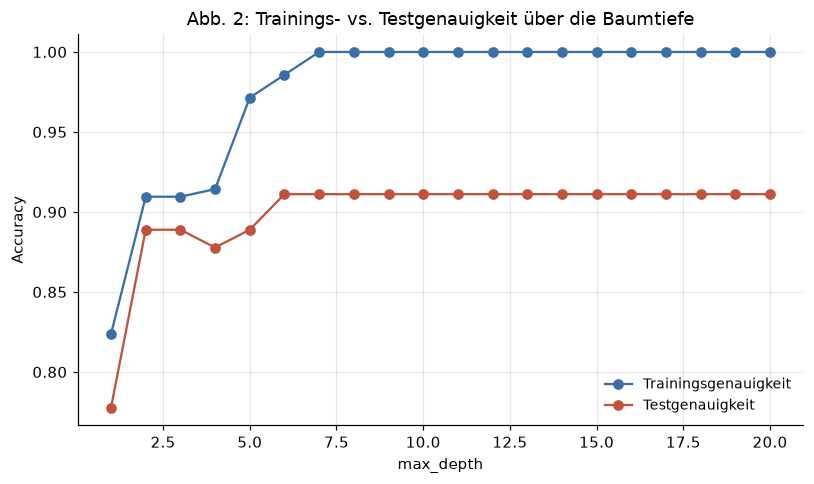

Beste Testgenauigkeit bei max_depth=6: 0.9111


In [5]:
depth_grid = np.arange(1, 21)
train_curve, test_curve = [], []
for depth in depth_grid:
    tree = DecisionTree(max_depth=int(depth), criterion="gini").fit(X_train, y_train)
    train_curve.append(accuracy(y_train, tree.predict(X_train)))
    test_curve.append(accuracy(y_test, tree.predict(X_test)))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(depth_grid, train_curve, "o-", color="#3b6ea5", label="Trainingsgenauigkeit")
ax.plot(depth_grid, test_curve, "o-", color="#c1523d", label="Testgenauigkeit")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Abb. 2: Trainings- vs. Testgenauigkeit über die Baumtiefe")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

best_depth = int(depth_grid[np.argmax(test_curve)])
print(f"Beste Testgenauigkeit bei max_depth={best_depth}: {max(test_curve):.4f}")

**Interpretation.** Die Trainingsgenauigkeit steigt monoton mit `max_depth` und
erreicht bei hinreichender Tiefe nahezu $100\,\%$ — der Baum lernt schließlich das
Rauschen der Trainingsmenge auswendig. Die Testgenauigkeit erreicht dagegen ein Maximum
bei moderater Tiefe und fällt danach, ein Lehrbuchbeispiel für die
Bias-Varianz-Kurve aus Notebook 00, Abschnitt 5, hier direkt als Funktion eines
einzelnen Hyperparameters statt einer Modellklasse (dort Polynomgrad) beobachtet.

### 5.2 Gini vs. Entropie

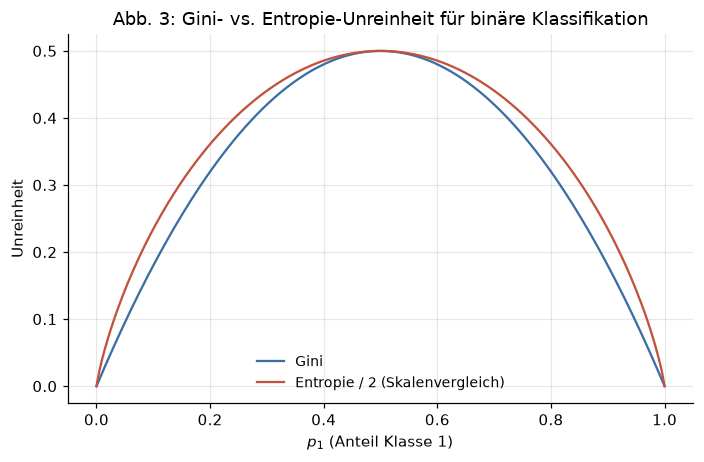

gini    : Test-Accuracy = 0.9111
entropy : Test-Accuracy = 0.9222


In [6]:
p_grid = np.linspace(1e-6, 1 - 1e-6, 200)
gini = 1 - (p_grid**2 + (1 - p_grid) ** 2)
entropy = -(p_grid * np.log2(p_grid) + (1 - p_grid) * np.log2(1 - p_grid))

fig, ax = plt.subplots(figsize=(6.5, 4.3))
ax.plot(p_grid, gini, label="Gini", color="#3b6ea5")
ax.plot(p_grid, entropy / 2, label="Entropie / 2 (Skalenvergleich)", color="#c1523d")
ax.set_xlabel(r"$p_1$ (Anteil Klasse 1)")
ax.set_ylabel("Unreinheit")
ax.set_title("Abb. 3: Gini- vs. Entropie-Unreinheit für binäre Klassifikation")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

for criterion in ["gini", "entropy"]:
    tree = DecisionTree(max_depth=best_depth, criterion=criterion).fit(X_train, y_train)
    print(f"{criterion:8s}: Test-Accuracy = {accuracy(y_test, tree.predict(X_test)):.4f}")

**Interpretation.** Auf $[0,1]$ skaliert und näherungsweise übereinandergelegt zeigen
Gini und Entropie nahezu identische Kurvenformen; entsprechend unterscheiden sich die
resultierenden Bäume in Praxis meist nur geringfügig, was sich auch in der
Testgenauigkeit widerspiegelt. Gini wird häufig aus Effizienzgründen bevorzugt (kein
Logarithmus).

### 5.3 Instabilität: Sensitivität gegenüber der Trainingsmenge

Anders als die parametrischen Modelle der Notebooks 01–02, deren Koeffizienten sich
bei kleinen Datenänderungen nur graduell verschieben, können sich Entscheidungsbäume
bereits durch das Entfernen weniger Punkte strukturell ändern — eine direkte Folge der
gierigen, diskreten Split-Suche (Abschnitt 1.3).

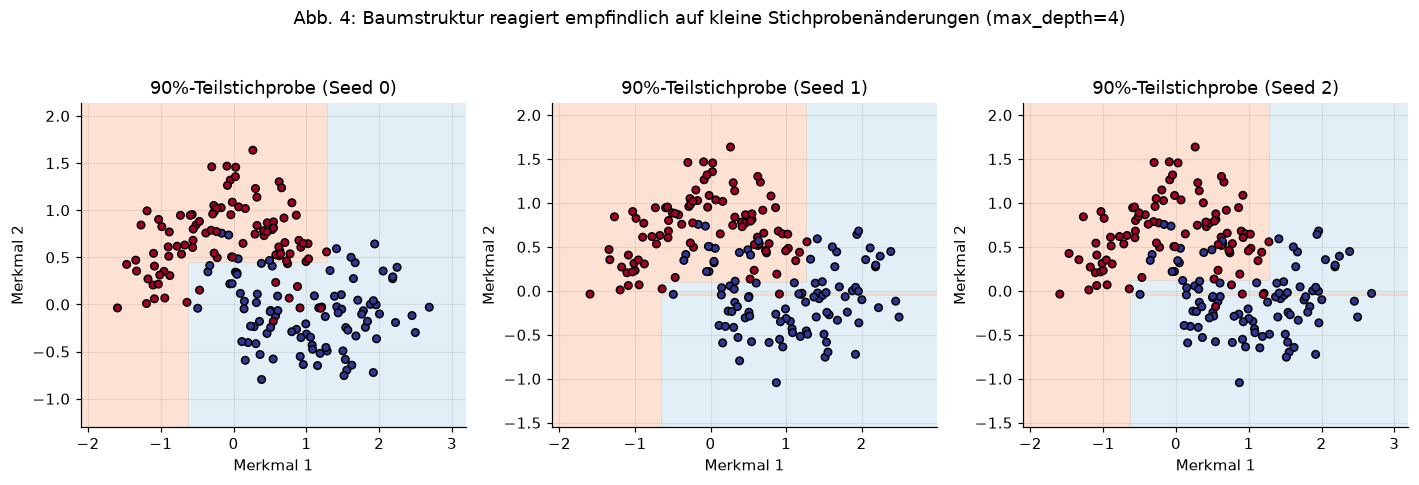

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.2))
for seed, ax in zip([0, 1, 2], axes):
    gen = np.random.default_rng(seed)
    subsample_idx = gen.choice(len(X_train), size=int(0.9 * len(X_train)), replace=False)
    tree = DecisionTree(max_depth=4, criterion="gini").fit(
        X_train[subsample_idx], y_train[subsample_idx]
    )
    plot_decision_boundary(tree, X_train[subsample_idx], y_train[subsample_idx],
                            f"90%-Teilstichprobe (Seed {seed})", ax)
fig.suptitle("Abb. 4: Baumstruktur reagiert empfindlich auf kleine Stichprobenänderungen "
             "(max_depth=4)", y=1.04)
plt.tight_layout()
plt.show()

**Interpretation.** Trotz nahezu identischer Trainingsdaten (nur $10\,\%$ zufällig
entfernt) unterscheiden sich die resultierenden Entscheidungsgrenzen sichtbar in Lage
und Anzahl der Splits. Diese hohe Varianz einzelner Bäume ist die zentrale Motivation
für **Bagging** und **Random Forests** (Breiman, 2001): Durch Mittelung vieler auf
Bootstrap-Stichproben trainierter Bäume wird die Varianz reduziert, ohne den Bias
wesentlich zu erhöhen (Notebook 00, Abschnitt 5) — ein Thema, das über den Rahmen
dieses Notebooks hinausgeht.

### 5.4 Interpretierbarkeit und Merkmalswichtigkeit

In [8]:
tree_final = DecisionTree(max_depth=3, criterion="gini").fit(X_train, y_train)
print("Baumstruktur (max_depth=3):\n")
tree_final.print_tree()

importances = tree_final.feature_importances(n_features=X_train.shape[1])
print("\nMerkmalswichtigkeit (normierter Unreinheitsrückgang):")
for j, imp in enumerate(importances):
    print(f"  Merkmal {j}: {imp:.4f}")

Baumstruktur (max_depth=3):

x[1] <= 0.118  (gini=0.500, n=210)
  x[0] <= -0.640  (gini=0.187, n=86)
    Blatt: Klasse 0 (n=5)
    x[1] <= -0.046  (gini=0.094, n=81)
      Blatt: Klasse 1 (n=59)
      Blatt: Klasse 1 (n=22)
  x[0] <= 1.277  (gini=0.350, n=124)
    x[1] <= 0.506  (gini=0.234, n=111)
      Blatt: Klasse 0 (n=36)
      Blatt: Klasse 0 (n=75)
    Blatt: Klasse 1 (n=13)

Merkmalswichtigkeit (normierter Unreinheitsrückgang):
  Merkmal 0: 0.3406
  Merkmal 1: 0.6594


**Interpretation.** Im Gegensatz zu k-NN lässt sich die Klassifikationsregel des Baums
direkt als Folge von Schwellenwertvergleichen ablesen — ein zentraler praktischer
Vorteil in Anwendungen, in denen Nachvollziehbarkeit gefordert ist (z.\,B. Kreditvergabe,
Medizin). Die Merkmalswichtigkeit quantifiziert, wie stark jedes Merkmal über alle
Splits hinweg zur Unreinheitsreduktion beiträgt — hier sind, dem Konstruktionsprinzip
der Halbmonde entsprechend, beide Merkmale von Bedeutung.

### 5.5 Validierung gegen `scikit-learn`

In [9]:
from sklearn.tree import DecisionTreeClassifier

reference = DecisionTreeClassifier(
    max_depth=best_depth, criterion="gini", random_state=RANDOM_STATE
).fit(X_train, y_train)

own_tree = DecisionTree(max_depth=best_depth, criterion="gini").fit(X_train, y_train)

acc_own = accuracy(y_test, own_tree.predict(X_test))
acc_ref = accuracy(y_test, reference.predict(X_test))

print(f"Eigenimplementierung — Test-Accuracy: {acc_own:.4f}")
print(f"scikit-learn         — Test-Accuracy: {acc_ref:.4f}")
print(f"Differenz: {abs(acc_own - acc_ref):.4f}")

Eigenimplementierung — Test-Accuracy: 0.9111
scikit-learn         — Test-Accuracy: 0.9333
Differenz: 0.0222


**Interpretation.** Kleine verbleibende Unterschiede zu `scikit-learn` resultieren aus
Implementierungsdetails bei Gleichständen im Informationsgewinn und der internen
Sortierstrategie, nicht aus einem abweichenden Algorithmus — beide Implementierungen
folgen demselben gierigen CART-Prinzip (Abschnitt 1.3).

<a id="6"></a>
## 6 Diskussion und Grenzen

**Ergebnis.** Der Entscheidungsbaum erzeugt eine achsenparallele, aber flexible
Entscheidungsgrenze und liefert bei geeigneter Tiefenbegrenzung Testgenauigkeit nahe
der von k-NN, bei gleichzeitig direkt interpretierbaren Regeln.

**Methodische Einschränkungen.**

1. *Gierige Suche.* Der Algorithmus optimiert jeden Split lokal; ein global optimaler
   Baum zu finden ist NP-vollständig (Hyafil & Rivest, 1976) und in der Praxis nicht
   handhabbar.
2. *Hohe Varianz einzelner Bäume.* Abschnitt 5.3 zeigt die Instabilität gegenüber
   kleinen Stichprobenänderungen — der Grund für Ensemble-Verfahren.
3. *Achsenparallele Grenzen.* Diagonale Klassengrenzen erfordern viele Splits zur
   Approximation (Treppenmuster); Modelle mit schrägen oder gekrümmten Grenzen
   (logistische Regression mit Wechselwirkungstermen, neuronale Netze) sind hier
   effizienter.
4. *Kein eingebautes Konfidenzmaß.* Blätter geben Klassenanteile, aber keine
   kalibrierten Wahrscheinlichkeiten im Sinne von Notebook 02, Abschnitt 6.4.

**Anschluss.** Notebook 05 kehrt zu einem probabilistischen, aber deutlich einfacheren
Modell zurück (Naive Bayes) und zeigt, wie eine explizite (wenn auch vereinfachende)
Verteilungsannahme sehr wenige Trainingsdaten benötigt.

<a id="7"></a>
## 7 Übungsaufgaben

1. **Pruning.** Implementieren Sie *Cost-Complexity Pruning*: Bauen Sie einen
   vollständigen Baum und entfernen Sie iterativ den Teilbaum mit dem geringsten
   Verhältnis aus Unreinheitszunahme zu Blattreduktion. Vergleichen Sie die
   Testgenauigkeit mit der tiefenbegrenzten Variante aus Abschnitt 5.1.
2. **Minimale Knotengröße.** Untersuchen Sie den Effekt von `min_samples_split` bei
   fester großer `max_depth` als alternative Regularisierung.
3. **Diagonale Klassengrenze.** Erzeugen Sie einen Datensatz mit einer diagonalen
   linearen Trennlinie (`make_classification` mit rotierten Merkmalen) und vergleichen
   Sie die benötigte `max_depth` für hohe Genauigkeit mit der logistischen Regression
   aus Notebook 02.
4. **Regressionsbaum.** Passen Sie `_impurity` auf die Varianz und `value` auf den
   Mittelwert an, um einen Regressionsbaum zu erhalten. Testen Sie ihn auf den
   simulierten Gehaltsdaten aus Notebook 01.
5. **Bagging von Hand.** Trainieren Sie 50 Bäume auf Bootstrap-Stichproben der
   Trainingsmenge und mitteln Sie deren Vorhersagen (Mehrheitsentscheid). Vergleichen
   Sie die resultierende Entscheidungsgrenze und Testgenauigkeit mit einem einzelnen
   Baum gleicher Tiefe (Vorgriff auf Random Forests).

<a id="8"></a>
## 8 Literatur

* Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). *Classification and
  Regression Trees*. Wadsworth.
* Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.
* Hyafil, L., & Rivest, R. L. (1976). Constructing optimal binary decision trees is
  NP-complete. *Information Processing Letters*, 5(1), 15–17.
* Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical
  Learning* (2. Aufl.). Springer. Kap. 9.